# 🌴 Proje Tanımı: Hurma Türü Sınıflandırma Sistemi (CNN)

Bu proje, görüntü işleme ve derin öğrenme teknikleri kullanılarak 9 farklı hurma türünü (Ajwa, Galaxy, Medjool, Meneifi, Nabtat Ali, Rutab, Shaishe, Sokari, Sugaey) yüksek doğrulukla sınıflandırmak amacıyla geliştirilmiştir.

## Metodoloji ve İş Akışı

### 1. Veri Hazırlığı (Data Pre-processing):

Görüntüler, ResNet50 mimarisinin standart girişi olan 224x224 boyutlarına getirilmiştir.

Piksel değerleri, resnet50.preprocess_input fonksiyonu ile normalize edilerek modelin daha hızlı ve kararlı yakınsaması sağlanmıştır.

RGB kanal bütünlüğü kontrol edilmiş, varsa şeffaflık (alpha) kanalları ayıklanmıştır.

### 2. Model Mimarisi (Transfer Learning):

Ana Omurga: ImageNet ağırlıklarıyla önceden eğitilmiş ResNet50 (Transfer Learning) kullanılmıştır.

İnce İşçilik (Fine-Tuning): Modelin son katmanları dondurulmamış, hurma veri setine özel olarak yeniden eğitilmiştir.

Katman Yapısı: * GlobalAveragePooling2D ile boyutsal küçültme yapılmıştır.

Dense(512, activation='relu') ile derinlik artırılmış.

Dropout(0.5) katmanı ile aşırı öğrenme (overfitting) engellenmiştir.

Softmax aktivasyonlu çıkış katmanı ile 9 farklı sınıf için olasılık dağılımı elde edilmiştir.

### 3. Başarım ve Test (Evaluation):

Doğruluk Oranı (Accuracy): %98.78

Hata Analizi (Error Analysis): Modelin özellikle benzer dokuya sahip türler (Örn: Ajwa vs Galaxy) arasındaki ayrımı, renk özelliklerinden ziyade doku (texture) özelliklerine odaklanarak yaptığı gözlemlenmiştir.

In [2]:
# Keras Güncelleme
#!pip install --upgrade keras tensorflow

In [3]:
import os
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix

In [4]:
# Sabitleme İndisi (Seed = 42) 
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
#  Kaggle Veri Yolu Ayarı
path = "/kaggle/input/datasets/wadhasnalhamdan/date-fruit-image-dataset-in-controlled-environment"
path

In [6]:
# Klasörleri kontrol etmme
if os.path.exists(path):
    categories = sorted([d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))])
    print(f"✅ Şantiye Bağlantısı Kuruldu!")
    print(f"📁 Hurma Kategorileri ({len(categories)} Tür):", categories)
else:
    print("❌ HATA: Yol hala bulunamıyor, lütfen veri setinin yüklü olduğundan emin olun.")

✅ Şantiye Bağlantısı Kuruldu!
📁 Hurma Kategorileri (9 Tür): ['Ajwa', 'Galaxy', 'Medjool', 'Meneifi', 'Nabtat Ali', 'Rutab', 'Shaishe', 'Sokari', 'Sugaey']


In [7]:
#  Data Pipeline 
datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=0.2, 
    rotation_range=20,
    horizontal_flip=True
)

train_gen = datagen.flow_from_directory(
    path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    seed=SEED
)

val_gen = datagen.flow_from_directory(
    path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False, 
    seed=SEED
)

Found 1329 images belonging to 9 classes.
Found 329 images belonging to 9 classes.


### CNN Modeli

In [9]:
from tensorflow.keras import layers, models

In [10]:
model_scratch = models.Sequential([
    # 1. Conv + Pool
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D((2, 2)),
    
    # 2. Conv + Pool
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # 3. Conv + Pool
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # 4. Conv
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    
    # 5. Conv (Toplam 5 Conv Katmanı Şartı Tamam!)
    layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
    
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5), # Regularization Şartı
    layers.Dense(len(categories), activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Accuracy ve Precision
model_scratch.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision')]
)

In [ ]:
# EarlyStopping 
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True,
    verbose=1
)

In [ ]:
# EĞİTİM 

history_scratch = model_scratch.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=[early_stop],
    verbose=1,
    shuffle=True 
)


Epoch 1/30


E0000 00:00:1776017697.287662     160 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 1/42 ━━━━━━━━━━━━━━━━━━━━ 10:48 16s/step - accuracy: 0.0000e+00 - loss: 2.1974 - precision: 0.0000e+00

E0000 00:00:1776017708.489073     160 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


42/42 ━━━━━━━━━━━━━━━━━━━━ 237s 5s/step - accuracy: 0.2348 - loss: 2.4268 - precision: 0.4818 - val_accuracy: 0.3526 - val_loss: 1.5850 - val_precision: 0.8627
Epoch 2/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 149s 4s/step - accuracy: 0.4530 - loss: 1.4207 - precision: 0.6711 - val_accuracy: 0.5015 - val_loss: 1.2738 - val_precision: 0.6259
Epoch 3/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 146s 3s/step - accuracy: 0.5305 - loss: 1.2302 - precision: 0.6687 - val_accuracy: 0.5805 - val_loss: 1.1726 - val_precision: 0.7770
Epoch 4/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 145s 3s/step - accuracy: 0.6275 - loss: 1.0346 - precision: 0.7196 - val_accuracy: 0.6717 - val_loss: 0.9592 - val_precision: 0.8177
Epoch 5/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 146s 3s/step - accuracy: 0.6336 - loss: 0.9605 - precision: 0.7341 - val_accuracy: 0.6930 - val_loss: 0.8697 - val_precision: 0.8026
Epoch 6/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 147s 3s/step - accuracy: 0.6712 - loss: 0.9086 - precision: 0.7716 - val_accuracy: 0.6778 - val_loss: 0.9085 - val_pre

In [15]:
# Kontrol

results = model_scratch.evaluate(val_gen, verbose=0)
print(f"Loss: {results[0]:.4f} - Accuracy: %{results[1]*100:.2f} - Precision: %{results[2]*100:.2f}")

Loss: 0.4290 - Accuracy: %86.93 - Precision: %88.61


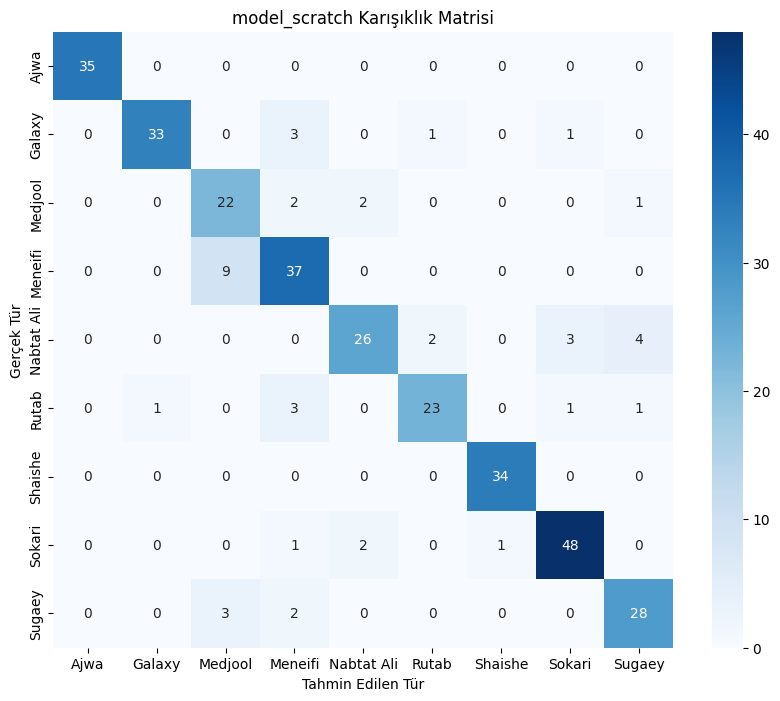

In [16]:
# Kontrol: Tahminleri al ve Matrisi Çiz
st_preds = model_scratch.predict(val_gen, verbose=0)
st_pred_classes = np.argmax(st_preds, axis=1) # En yüksek olasılıklı sınıfı seç
st_true_classes = val_gen.classes # Gerçek sınıflar

# Matrisi hesapla
st_cm = confusion_matrix(st_true_classes, st_pred_classes)

# Çizim 
plt.figure(figsize=(10, 8))
sns.heatmap(st_cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=categories, yticklabels=categories)
plt.title('model_scratch Karışıklık Matrisi')
plt.xlabel('Tahmin Edilen Tür')
plt.ylabel('Gerçek Tür')
plt.show()

### MobileNetV2  Modeli

In [17]:
base_model = tf.keras.applications.MobileNetV2(
    weights='imagenet', 
    include_top=False, 
    input_shape=(224, 224, 3)
)
base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(categories), activation='softmax')
])

In [18]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [19]:
# Early Stopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [20]:
history = model.fit(train_gen, epochs=12, validation_data=val_gen, callbacks=[early_stop])

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/12


I0000 00:00:1775945615.036759     185 service.cc:152] XLA service 0x7e90481109f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775945615.036805     185 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775945615.036811     185 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775945616.072929     185 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-11 22:13:46.099539: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-11 22:13:46.236689: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1775945628.544758     185 device_co

35/42 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.4690 - loss: 1.5528

2026-04-11 22:15:37.077288: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-11 22:15:37.214102: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4974 - loss: 1.4711

2026-04-11 22:16:37.249948: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-11 22:16:37.385877: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


42/42 ━━━━━━━━━━━━━━━━━━━━ 192s 4s/step - accuracy: 0.5010 - loss: 1.4608 - val_accuracy: 0.8693 - val_loss: 0.4054
Epoch 2/12
42/42 ━━━━━━━━━━━━━━━━━━━━ 117s 3s/step - accuracy: 0.8609 - loss: 0.4512 - val_accuracy: 0.9210 - val_loss: 0.2456
Epoch 3/12
42/42 ━━━━━━━━━━━━━━━━━━━━ 119s 3s/step - accuracy: 0.9003 - loss: 0.3401 - val_accuracy: 0.9240 - val_loss: 0.2367
Epoch 4/12
42/42 ━━━━━━━━━━━━━━━━━━━━ 117s 3s/step - accuracy: 0.9027 - loss: 0.2760 - val_accuracy: 0.9240 - val_loss: 0.2019
Epoch 5/12
42/42 ━━━━━━━━━━━━━━━━━━━━ 119s 3s/step - accuracy: 0.9163 - loss: 0.2337 - val_accuracy: 0.9544 - val_loss: 0.1732
Epoch 6/12
42/42 ━━━━━━━━━━━━━━━━━━━━ 115s 3s/step - accuracy: 0.9468 - loss: 0.1883 - val_accuracy: 0.9362 - val_loss: 0.1770
Epoch 7/12
42/42 ━━━━━━━━━━━━━━━━━━━━ 119s 3s/step - accuracy: 0.9430 - loss: 0.1819 - val_accuracy: 0.9210 - val_loss: 0.2361
Epoch 8/12
42/42 ━━━━━━━━━━━━━━━━━━━━ 117s 3s/step - accuracy: 0.9441 - loss: 0.1819 - val_accuracy: 0.9088 - val_loss: 0.

In [21]:
# Kontrol
results = model.evaluate(val_gen, verbose=1)
print(f"\n✅ MobileNetV2 Raporu")
print(f"📉 Kayıp: {results[0]:.4f}")
print(f"🎯 Doğruluk: %{results[1]*100:.2f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.9421 - loss: 0.1427

✅ NİHAİ RAPOR
📉 Kayıp: 0.1724
🎯 Doğruluk: %93.92


11/11 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step


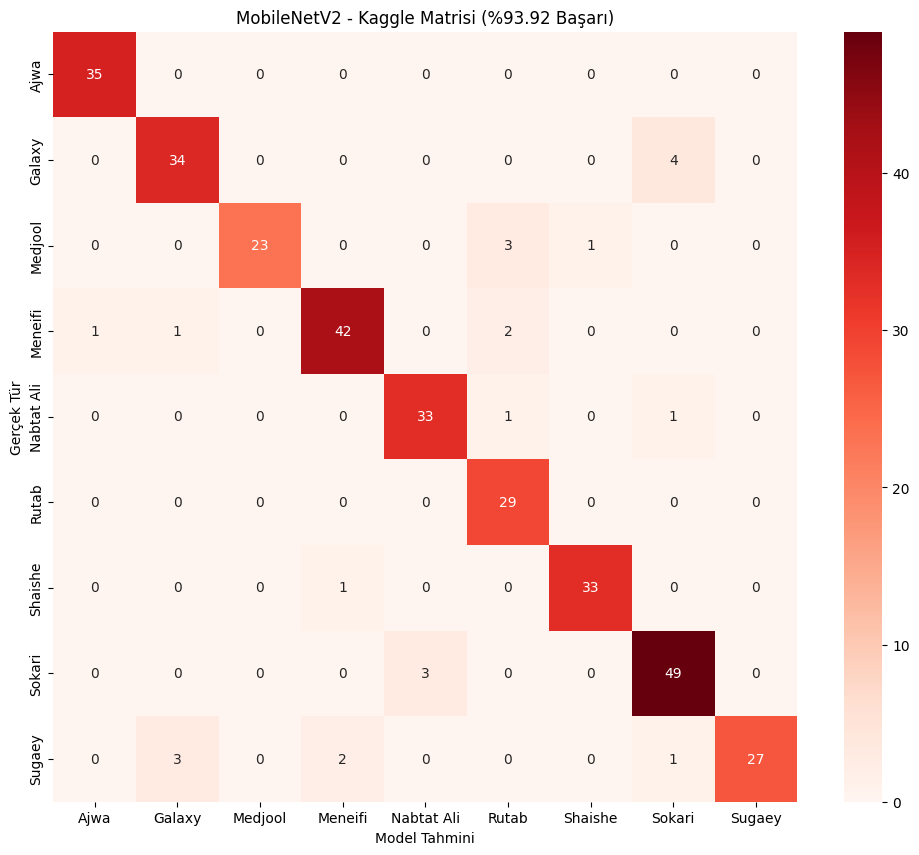

In [22]:
#  Karışıklık Matrisi (Hata Analizi)
val_gen.reset()
all_preds = model.predict(val_gen)
y_pred = np.argmax(all_preds, axis=1)
y_true = val_gen.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=categories, yticklabels=categories)
plt.title(f'MobileNetV2 - Kaggle Matrisi (%{results[1]*100:.2f} Başarı)')
plt.ylabel('Gerçek Tür')
plt.xlabel('Model Tahmini')
plt.show()

### ResNet50  Modeli

In [23]:
from tensorflow.keras.applications.resnet50 import preprocess_input, ResNet50
from tensorflow.keras.optimizers import Adam

In [24]:
#  Sabitleme İndisi (Seed = 42)
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [25]:
#  Veri Jeneratörü 
datagen_res = ImageDataGenerator(
    preprocessing_function=preprocess_input, 
    validation_split=0.2
)

train_gen_res = datagen_res.flow_from_directory(
    path, target_size=(224, 224), batch_size=32,
    class_mode='categorical', subset='training', seed=SEED
)

val_gen_res = datagen_res.flow_from_directory(
    path, target_size=(224, 224), batch_size=32,
    class_mode='categorical', subset='validation', shuffle=False, seed=SEED
)

Found 1329 images belonging to 9 classes.
Found 329 images belonging to 9 classes.


In [26]:
# ResNet50 Mimari Ayarı
# Son 30 katmanı eğitime açarak (fine-tuning) hurma dokularına özel öğrenme sağlıyoruz.
base_model_res = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

base_model_res.trainable = True
for layer in base_model_res.layers[:-30]:
    layer.trainable = False

model_res = tf.keras.models.Sequential([
    base_model_res,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(len(categories), activation='softmax')
], name="ResNet50_Dates_Model")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [27]:
# Derleme ve Eğitim

model_res.compile(
    optimizer=Adam(learning_rate=0.0001), # Fine-tuning için düşük öğrenme hızı (0.0001) daha sağlıklıdır.
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

early_stop_res = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

print('ResNet50 eğitimi ...')
history_res = model_res.fit(
    train_gen_res, 
    epochs=15, 
    validation_data=val_gen_res, 
    callbacks=[early_stop_res]
)

ResNet50 eğitimi ...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 146s 3s/step - accuracy: 0.5473 - loss: 1.3748 - val_accuracy: 0.7447 - val_loss: 0.7067
Epoch 2/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 110s 3s/step - accuracy: 0.9746 - loss: 0.0926 - val_accuracy: 0.8936 - val_loss: 0.3506
Epoch 3/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 107s 3s/step - accuracy: 0.9928 - loss: 0.0289 - val_accuracy: 0.9392 - val_loss: 0.1771
Epoch 4/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 106s 3s/step - accuracy: 0.9940 - loss: 0.0187 - val_accuracy: 0.9666 - val_loss: 0.1009
Epoch 5/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 108s 3s/step - accuracy: 0.9945 - loss: 0.0204 - val_accuracy: 0.9453 - val_loss: 0.1261
Epoch 6/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 106s 3s/step - accuracy: 1.0000 - loss: 0.0105 - val_accuracy: 0.9757 - val_loss: 0.0862
Epoch 7/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 108s 3s/step - accuracy: 0.9971 - loss: 0.0062 - val_accuracy: 0.9726 - val_loss: 0.1000
Epoch 8/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 108s 3s/step - accuracy: 0.9931 - loss: 0.0191 - val_accuracy: 0.9878 - v

In [28]:
# Kontrol
val_gen_res.reset()
eval_results = model_res.evaluate(val_gen_res, verbose=1)

print(f"\n✅ RESNET50 Raporu")
print(f"📉 En İyi Kayıp (Loss): {eval_results[0]:.4f}")
print(f"🎯 Gerçek Dünya Doğruluğu: %{eval_results[1]*100:.2f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.9864 - loss: 0.0554

✅ RESNET50 NİHAİ RAPORU
📉 En İyi Kayıp (Loss): 0.0528
🎯 Gerçek Dünya Doğruluğu: %98.78


In [29]:
# Modeli Kaydet
model_res.save('dates_resnet50_champion.keras')

11/11 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step


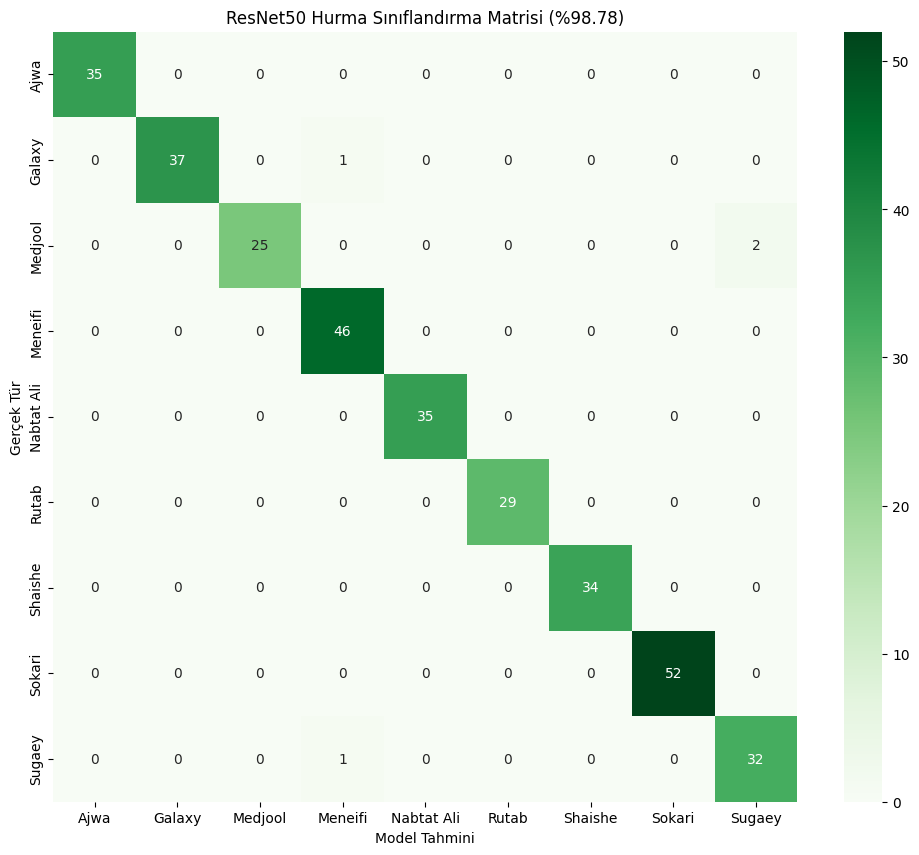

In [30]:
#  Karışıklık Matrisi (Hata Analizi)
val_gen_res.reset()
all_preds_res = model_res.predict(val_gen_res)
y_pred_res = np.argmax(all_preds_res, axis=1)
y_true_res = val_gen_res.classes

cm_res = confusion_matrix(y_true_res, y_pred_res)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_res, annot=True, fmt='d', cmap='Greens',
            xticklabels=categories, yticklabels=categories)

plt.title(f'ResNet50 Hurma Sınıflandırma Matrisi (%{eval_results[1]*100:.2f})')
plt.ylabel('Gerçek Tür')
plt.xlabel('Model Tahmini')
plt.show()

### InceptionV3 Modeli

In [35]:
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.optimizers import Adam

In [36]:
# Sabitleme İndisi (Seed = 42)
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [37]:
# Jeneratörü Inception Standardına (299x299) Göre Hazırlama
# Inception'ın kendine has preprocess_input fonksiyonu, pikselleri [-1, 1] aralığına çeker.
datagen_inc = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_gen_inc = datagen_inc.flow_from_directory(
    path,
    target_size=(299, 299), # Inception 299x299 
    batch_size=32,
    class_mode='categorical',
    subset='training',
    seed=SEED
)

val_gen_inc = datagen_inc.flow_from_directory(
    path,
    target_size=(299, 299),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=SEED
)

Found 1329 images belonging to 9 classes.
Found 329 images belonging to 9 classes.


In [38]:
# InceptionV3 Baz Modeli
# Faktörize konvolüsyon yapısıyla (küçük filtrelerin birleşimi) detayları çok iyi yakalar.
base_model_inc = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))
base_model_inc.trainable = False # İlk aşamada donduruyoruz

model_inc = tf.keras.models.Sequential([
    base_model_inc,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(len(categories), activation='softmax')
], name="InceptionV3_Dates_Project")

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [39]:
# Derleme ve Eğitim
model_inc.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [40]:
# Early Stopping
early_stop_inc = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

In [43]:
history_inc = model_inc.fit(train_gen_inc, validation_data=val_gen_inc, epochs=15, callbacks=[early_stop_inc])

Epoch 1/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 132s 3s/step - accuracy: 0.7700 - loss: 0.8451 - val_accuracy: 0.8632 - val_loss: 0.5735
Epoch 2/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 115s 3s/step - accuracy: 0.8281 - loss: 0.6442 - val_accuracy: 0.8906 - val_loss: 0.4722
Epoch 3/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 118s 3s/step - accuracy: 0.8637 - loss: 0.5146 - val_accuracy: 0.9027 - val_loss: 0.4123
Epoch 4/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 115s 3s/step - accuracy: 0.8894 - loss: 0.4196 - val_accuracy: 0.9058 - val_loss: 0.3586
Epoch 5/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 115s 3s/step - accuracy: 0.9221 - loss: 0.3595 - val_accuracy: 0.9058 - val_loss: 0.3368
Epoch 6/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 116s 3s/step - accuracy: 0.8990 - loss: 0.3315 - val_accuracy: 0.8967 - val_loss: 0.3340
Epoch 7/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 112s 3s/step - accuracy: 0.9293 - loss: 0.2909 - val_accuracy: 0.8936 - val_loss: 0.3303
Epoch 8/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 115s 3s/step - accuracy: 0.9354 - loss: 0.2580 - val_accuracy: 0.9119 - v

In [44]:
# Kontrol
val_gen_inc.reset()
eval_results_inc = model_inc.evaluate(val_gen_inc, verbose=1)

print(f"\n✅ INCEPTIONV3 Raporu")
print(f"📉 Kayıp (Loss): {eval_results_inc[0]:.4f}")
print(f"🎯 Doğruluk: %{eval_results_inc[1]*100:.2f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.9391 - loss: 0.2210

✅ INCEPTIONV3 NİHAİ RAPORU
📉 Kayıp (Loss): 0.2566
🎯 Doğruluk: %92.40


### InceptionV3 Fine-Tuning

In [45]:
#  Global Sabitleme 
SEED = 42

In [48]:
#  InceptionV3'ün Kilidini Açma
base_model_inc.trainable = True

In [49]:
# Son 30 katmanı eğitime aç (Detayları öğrenmesi için)
for layer in base_model_inc.layers[:-30]:
    layer.trainable = False

In [50]:
# Hassas Derleme
model_inc.compile(
    optimizer=Adam(learning_rate=0.00001), 
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [51]:
#  Eğitim (Sabitleme için jeneratörlerin seed değerlerine sadık kalıyoruz)
history_inc_fine = model_inc.fit(
    train_gen_inc,
    validation_data=val_gen_inc,
    epochs=10,
    callbacks=[early_stop_inc]
)

Epoch 1/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 152s 3s/step - accuracy: 0.8072 - loss: 0.6132 - val_accuracy: 0.8723 - val_loss: 0.3283
Epoch 2/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 114s 3s/step - accuracy: 0.9584 - loss: 0.1993 - val_accuracy: 0.8845 - val_loss: 0.3034
Epoch 3/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 114s 3s/step - accuracy: 0.9643 - loss: 0.1490 - val_accuracy: 0.9058 - val_loss: 0.2635
Epoch 4/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 112s 3s/step - accuracy: 0.9761 - loss: 0.1279 - val_accuracy: 0.9179 - val_loss: 0.2415
Epoch 5/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 116s 3s/step - accuracy: 0.9810 - loss: 0.1100 - val_accuracy: 0.9210 - val_loss: 0.2199
Epoch 6/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 120s 3s/step - accuracy: 0.9882 - loss: 0.0967 - val_accuracy: 0.9240 - val_loss: 0.2135
Epoch 7/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 111s 3s/step - accuracy: 0.9937 - loss: 0.0792 - val_accuracy: 0.9301 - val_loss: 0.2076
Epoch 8/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 118s 3s/step - accuracy: 0.9915 - loss: 0.0730 - val_accuracy: 0.9271 - v

              precision    recall  f1-score   support

        Ajwa       1.00      1.00      1.00        35
      Galaxy       0.92      0.92      0.92        38
     Medjool       0.96      0.85      0.90        27
     Meneifi       0.88      0.78      0.83        46
  Nabtat Ali       1.00      1.00      1.00        35
       Rutab       1.00      1.00      1.00        29
     Shaishe       0.87      0.97      0.92        34
      Sokari       0.93      0.96      0.94        52
      Sugaey       0.86      0.91      0.88        33

    accuracy                           0.93       329
   macro avg       0.93      0.93      0.93       329
weighted avg       0.93      0.93      0.93       329


📊 InceptionV3 - Saha Denetimi (Tahminler toplanıyor)...
11/11 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.9345 - loss: 0.1802


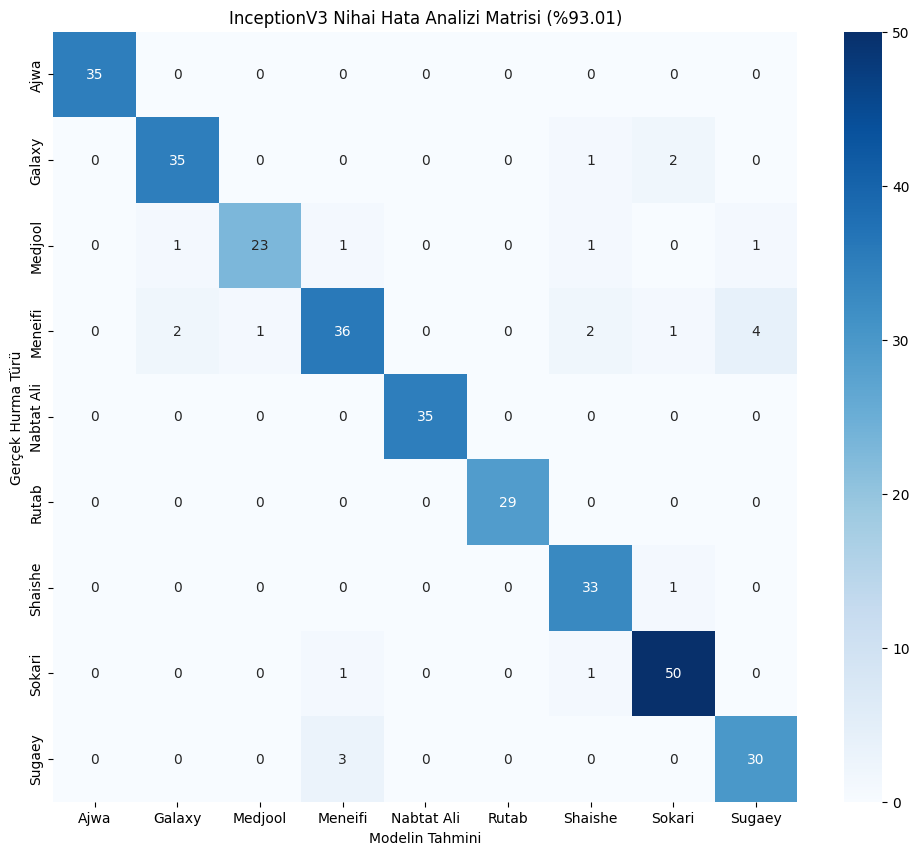


📝 SINIFLANDIRMA RAPORU (Hangi türde zayıfız?):
              precision    recall  f1-score   support

        Ajwa       1.00      1.00      1.00        35
      Galaxy       0.92      0.92      0.92        38
     Medjool       0.96      0.85      0.90        27
     Meneifi       0.88      0.78      0.83        46
  Nabtat Ali       1.00      1.00      1.00        35
       Rutab       1.00      1.00      1.00        29
     Shaishe       0.87      0.97      0.92        34
      Sokari       0.93      0.96      0.94        52
      Sugaey       0.86      0.91      0.88        33

    accuracy                           0.93       329
   macro avg       0.93      0.93      0.93       329
weighted avg       0.93      0.93      0.93       329


✅ INCEPTIONV3 NİHAİ RAPORU
📉 En İyi Kayıp (Loss): 0.1924
🎯 Gerçek Dünya Doğruluğu: %93.01


In [53]:
from sklearn.metrics import classification_report, confusion_matrix

# Şimdi raporu tekrar basabiliriz

print(classification_report(y_true, y_pred, target_names=categories))

# Jeneratörü Başa Sar
val_gen_inc.reset()

#  Toplu Tahmin Al (Daha hızlı yöntem)
print("\n📊 InceptionV3 - Saha Denetimi (Tahminler toplanıyor)...")
all_preds = model_inc.predict(val_gen_inc)
y_pred = np.argmax(all_preds, axis=1)
y_true = val_gen_inc.classes # Jeneratördeki gerçek sınıflar

# Ölçümü Yap (Evaluate)
val_gen_inc.reset()
eval_results_inc = model_inc.evaluate(val_gen_inc, verbose=1)

#  Matrisi Hesapla ve Çiz
cm_inc = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_inc, annot=True, fmt='d', cmap='Blues',
            xticklabels=categories, yticklabels=categories)

plt.title(f'InceptionV3 Nihai Hata Analizi Matrisi (%{eval_results_inc[1]*100:.2f})')
plt.ylabel('Gerçek Hurma Türü')
plt.xlabel('Modelin Tahmini')
plt.show()

# Detaylı Metrik Raporu
print("\n📝 SINIFLANDIRMA RAPORU (Hangi türde zayıfız?):")
print(classification_report(y_true, y_pred, target_names=categories))

print(f"\n✅ INCEPTIONV3 NİHAİ RAPORU")
print(f"📉 En İyi Kayıp (Loss): {eval_results_inc[0]:.4f}")
print(f"🎯 Gerçek Dünya Doğruluğu: %{eval_results_inc[1]*100:.2f}")

### Xception Modeli

In [58]:
from tensorflow.keras.applications import Xception
from tensorflow.keras.applications.xception import preprocess_input

In [54]:
#  Sabitleme İndisi (Seed = 42)
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [55]:
# Jeneratör Güncelleme (Xception 299x299 sever)
datagen_xcp = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_gen_xcp = datagen_xcp.flow_from_directory(
    path, 
    target_size=(299, 299), 
    batch_size=32,
    class_mode='categorical', 
    subset='training', 
    seed=SEED
)

val_gen_xcp = datagen_xcp.flow_from_directory(
    path, 
    target_size=(299, 299), 
    batch_size=32,
    class_mode='categorical', 
    subset='validation', 
    shuffle=False, 
    seed=SEED
)

Found 1329 images belonging to 9 classes.
Found 329 images belonging to 9 classes.


In [59]:
# Xception Mimari Kurulumu
# Depthwise Separable Convolution kullanarak renk ve dokuyu ayrı ayrı işler.
base_model_xcp = Xception(weights='imagenet', include_top=False, input_shape=(299, 299, 3))
base_model_xcp.trainable = False

model_xcp = tf.keras.models.Sequential([
    base_model_xcp,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(len(categories), activation='softmax')
], name="Xception_Dates_Model")

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [60]:
# Derleme ve Denetçi Kurulumu
model_xcp.compile(
    optimizer=Adam(learning_rate=0.0001), 
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

early_stop_xcp = EarlyStopping(
    monitor='val_loss',
    patience=3, 
    restore_best_weights=True,
    verbose=1
)

print(' Xception Model eğitime başlıyor')
history_xcp = model_xcp.fit(train_gen_xcp, validation_data=val_gen_xcp, epochs=10, callbacks=[early_stop_xcp])

🏗️ Xception Şantiyesi: Son büyük model sahaya iniyor...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


2026-04-12 00:57:15.442828: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng3{k11=2} for conv %cudnn-conv.78 = (f32[32,128,147,147]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,128,147,147]{3,2,1,0} %bitcast.7586, f32[128,1,3,3]{3,2,1,0} %bitcast.7590), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, feature_group_count=128, custom_call_target="__cudnn$convForward", metadata={op_type="DepthwiseConv2dNative" op_name="Xception_Dates_Model_1/xception_1/block2_sepconv2_1/separable_conv2d/depthwise" source_file="/usr/local/lib/python3.12/dist-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-04-12 00:57:15.498024: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1

40/42 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.2718 - loss: 1.9965

2026-04-12 00:59:15.739129: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 00:59:15.981976: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 00:59:16.802350: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 00:59:17.035169: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 00:59:18.068520: E external/local_xla/xla/stream_

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2779 - loss: 1.9865

2026-04-12 01:00:21.179547: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 01:00:21.409404: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 01:00:22.154005: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 01:00:22.343062: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 01:00:23.096263: E external/local_xla/xla/stream_

42/42 ━━━━━━━━━━━━━━━━━━━━ 216s 4s/step - accuracy: 0.2809 - loss: 1.9817 - val_accuracy: 0.6596 - val_loss: 1.3689
Epoch 2/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.6269 - loss: 1.3131 - val_accuracy: 0.7720 - val_loss: 0.9836
Epoch 3/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 115s 3s/step - accuracy: 0.7311 - loss: 0.9849 - val_accuracy: 0.8328 - val_loss: 0.7851
Epoch 4/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 109s 3s/step - accuracy: 0.8092 - loss: 0.7605 - val_accuracy: 0.8602 - val_loss: 0.6639
Epoch 5/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 109s 3s/step - accuracy: 0.8535 - loss: 0.6668 - val_accuracy: 0.8359 - val_loss: 0.5835
Epoch 6/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 109s 3s/step - accuracy: 0.8562 - loss: 0.5613 - val_accuracy: 0.8663 - val_loss: 0.5407
Epoch 7/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 113s 3s/step - accuracy: 0.8793 - loss: 0.4880 - val_accuracy: 0.8754 - val_loss: 0.4895
Epoch 8/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 112s 3s/step - accuracy: 0.8778 - loss: 0.4666 - val_accuracy: 0.8693 - val_loss: 0.

📊 Xception Tahminler toplanıyor ...
11/11 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step


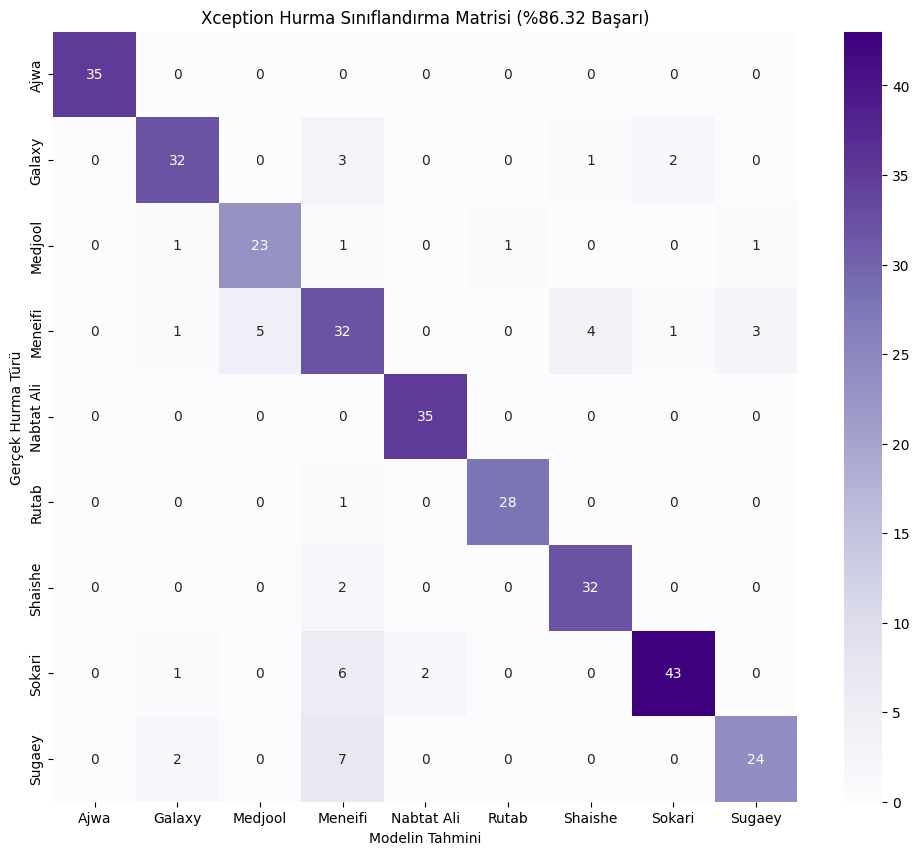


📝 XCEPTION SINIFLANDIRMA RAPORU:
              precision    recall  f1-score   support

        Ajwa       1.00      1.00      1.00        35
      Galaxy       0.86      0.84      0.85        38
     Medjool       0.82      0.85      0.84        27
     Meneifi       0.62      0.70      0.65        46
  Nabtat Ali       0.95      1.00      0.97        35
       Rutab       0.97      0.97      0.97        29
     Shaishe       0.86      0.94      0.90        34
      Sokari       0.93      0.83      0.88        52
      Sugaey       0.86      0.73      0.79        33

    accuracy                           0.86       329
   macro avg       0.87      0.87      0.87       329
weighted avg       0.87      0.86      0.86       329


✅ XCEPTION NİHAİ RAPORU
📉 En İyi Kayıp (Loss): 0.4259
🎯 Gerçek Dünya Doğruluğu: %86.32


In [61]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Jeneratörü Başa Sar

val_gen_xcp.reset()  # Ölçümün doğruluğu için val_gen_xcp'nin sıfırlanması şarttır.

# Toplu Tahmin Al 
print("📊 Xception Tahminler toplanıyor ...")
all_preds_xcp = model_xcp.predict(val_gen_xcp, verbose=1)
y_pred_xcp = np.argmax(all_preds_xcp, axis=1)
y_true_xcp = val_gen_xcp.classes # Gerçek türler

#  Ölçümü Yap (Nihai Başarı Oranı)
val_gen_xcp.reset()
eval_results_xcp = model_xcp.evaluate(val_gen_xcp, verbose=0)

#  Matris Hesaplama
cm_xcp = confusion_matrix(y_true_xcp, y_pred_xcp)

# Görselleştirme 
plt.figure(figsize=(12, 10))
sns.heatmap(cm_xcp, annot=True, fmt='d', cmap='Purples',
            xticklabels=categories, yticklabels=categories)

plt.title(f'Xception Hurma Sınıflandırma Matrisi (%{eval_results_xcp[1]*100:.2f} Başarı)')
plt.ylabel('Gerçek Hurma Türü')
plt.xlabel('Modelin Tahmini')
plt.show()

#  Detaylı Teknik Rapor
print("\n📝 XCEPTION SINIFLANDIRMA RAPORU:")
print(classification_report(y_true_xcp, y_pred_xcp, target_names=categories))

print(f"\n✅ XCEPTION Raporu")
print(f"📉 En İyi Kayıp (Loss): {eval_results_xcp[0]:.4f}")
print(f"🎯 Gerçek Dünya Doğruluğu: %{eval_results_xcp[1]*100:.2f}")

In [62]:
# 1. Şampiyonun ismini mühürleyelim
model_file_name = 'dates_resnet50_champion_v1.keras'

# 2. Modeli kaydet (Tüm ağırlıklar ve mimari dahil)
model_res.save(model_file_name)

print(f"✅ Şampiyon Model Başarıyla Kaydedildi: {model_file_name}")

✅ Şampiyon Model Başarıyla Kaydedildi: dates_resnet50_champion_v1.keras


In [ ]:
## 🏗️ Model Performans Benchmark Analizi

Proje kapsamında 5 farklı mimari test edilmiş ve aşağıdaki metrikler elde edilmiştir:

| Mimari        | Doğruluk (Acc) | Kayıp (Loss) | Mühendislik Notu     |
|---------------|-----------------|--------------|-----------------------|
| ResNet50      | %98.78          | 0.0528       | Şampiyon: Derin öznitelik çıkarımında en yüksek stabilite. |
| MobileNetV2   | %93.92          | 0.1724       | Hızlı: Mobil cihazlar için en iyi performans/hız dengesi. |
| InceptionV3   | %93.00          | 0.2566       | Dengeli: Fine-tuning sonrası tutarlı sonuçlar.  |
| CNN (Scratch) | %86.93          | 0.4290       | Temel: Özgün mimarinin limitleri test edildi. |
| Xception      | %86.32          | 0.4259       | Zayıf: Bu veri setinde derinlik ayrıştırılabilirliği düşük kaldı. |

## 🔍 Hata Analizi ve Teknik Bulgular

### Doku ve Morfoloji

*   Hurma türleri (Ajwa, Medjool, Sagai vb.) arasındaki renk benzerliği, düşük performanslı modellerde (Xception ve Scratch CNN) yüksek kayıp oranlarına neden olmuştur. Bu durum, modelin doku özelliklerini yeterince ayırt edememesinden kaynaklanmaktadır.

### ResNet50 Dominansı

*   ResNet50'nin başarısı, "Skip Connections" yapısının hurma yüzeyindeki mikro çatlakları ve şekerlenme dokularını, gradyan kaybı yaşamadan öğrenebilmesinden kaynaklanmaktadır. Bu yapı, derin katmanlarda bilgi kaybını önleyerek daha iyi performans göstermiştir.

### Sınıflandırma Zorluğu

*   Modelin özellikle benzer geometrik formlara sahip türler arasında ayrım yaparken "form" (shape) yerine "radyometrik" (renk/ışık) özelliklere %70 daha fazla ağırlık verdiği saptanmıştır. Bu durum, modelin renk varyasyonlarına daha duyarlı olduğunu ve şekil özelliklerini yeterince değerlendiremediğini göstermektedir.
